# 03 — Quantum Clustering Prototype (UBCF, Quantum-Only, Improved)

This notebook is fully quantum-focused for sparse user clustering:
- Fidelity-based quantum kernels from amplitude + angle feature maps
- IQP-style entanglement after `AngleEmbedding` (CNOT ring + `StronglyEntanglingLayers` with variational training)
- Swap Test fidelity checks and noisy NISQ realism (`shots=4096`, Aer when available)
- **Lloyd adiabatic VQE clustering**: distance Hamiltonian optimization for quantum centroid assignment
- **Polynomial kernel**: optional `kernel²` transformation for enhanced nonlinearity
- **Auto-k selection**: maximize Silhouette score across `k=4..10`
- Elbow sweep, silhouette (overall + per-cluster), Davies–Bouldin, and quantum inertia
- **UMAP default visualization** (`metric='precomputed'` on quantum distance matrix) + MDS comparison

**Research targets**:
- Silhouette score **>0.25** (improved from baseline)
- Cluster compactness and separability for sparse user vectors
- Aligned with Phase 3 quantum innovation (amplitude/angle + Swap Test + IQP entanglement)
- NISQ-compatible with practical scalability paths

**Note**: Install UMAP if not present: `pip install umap-learn`


Primary outputs:- `umap_quantum.png`, `mds_quantum.png`, `quantum_elbow.png`

- `quantum_user_labels_improved.npy`- `quantum_metrics.json`, `quantum_metrics.csv`, `quantum_elbow.csv`
- `kernel_matrix.npz`

In [1]:
# Cell 1 — Imports, constants, data load/normalize (quantum-only)
import json
import sys
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import MDS
from sklearn.metrics import davies_bouldin_score, silhouette_samples, silhouette_score
from sklearn.preprocessing import normalize

try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False

try:
    import pennylane as qml
    from pennylane import numpy as pnp
    PENNYLANE_AVAILABLE = True
except Exception:
    PENNYLANE_AVAILABLE = False

try:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector
    QISKIT_AVAILABLE = True
except Exception:
    QISKIT_AVAILABLE = False

try:
    from qiskit_aer import AerSimulator
    from qiskit_aer.noise import NoiseModel, depolarizing_error
    AER_AVAILABLE = True
except Exception:
    AER_AVAILABLE = False

if not PENNYLANE_AVAILABLE:
    raise ImportError("PennyLane is required for this notebook.")

SEED = 42
rng = np.random.default_rng(SEED)

IN_DIR = Path("data/processed_32m_ubcf")
OUT_DIR = Path("data/processed_32m_ubcf")
OUT_DIR.mkdir(parents=True, exist_ok=True)

N_QUBITS = 6
TARGET_DIM = 2 ** N_QUBITS
SAMPLE_USERS = 600

IQP_LAYERS = 2
K_MIN, K_MAX = 4, 10
MAX_ITERS = 30
KERNEL_ALPHA = 0.45
NOISY_SHOTS = 4096
NOISE_P = 0.01
KERNEL_WORKERS = 8

USE_STRONG_ENTANGLING = True
USE_AER_NOISY = True
use_dwave_sim = True

user_latent_full = np.load(IN_DIR / "user_latent.npy").astype(np.float32)

sample_idx = np.sort(
    rng.choice(np.arange(len(user_latent_full)), size=min(SAMPLE_USERS, len(user_latent_full)), replace=False)
)
X_latent = user_latent_full[sample_idx]

if X_latent.shape[1] < TARGET_DIM:
    X = np.pad(X_latent, ((0, 0), (0, TARGET_DIM - X_latent.shape[1])), mode="constant")
else:
    X = X_latent[:, :TARGET_DIM]
X_amp = normalize(X, norm="l2", axis=1).astype(np.float32)

ang_src = X_latent[:, :N_QUBITS]
med = np.median(ang_src, axis=0, keepdims=True)
iqr = np.subtract(*np.percentile(ang_src, [75, 25], axis=0, keepdims=True)) + 1e-8
X_ang = np.clip((ang_src - med) / iqr, -3.0, 3.0)
X_ang = ((X_ang + 3.0) / 6.0) * np.pi
X_ang = X_ang.astype(np.float32)

print(f"Python={sys.version.split()[0]} | PennyLane={PENNYLANE_AVAILABLE} | Qiskit={QISKIT_AVAILABLE} | Aer={AER_AVAILABLE} | UMAP={UMAP_AVAILABLE}")
print(f"sample={len(X_amp)} users | n_qubits={N_QUBITS} | target_dim={TARGET_DIM}")

c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\acolumban\AppData\Local\Temp\ipykernel_23856\1189763553.py:28: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


Python=3.9.13 | PennyLane=True | Qiskit=True | Aer=True | UMAP=True
sample=600 users | n_qubits=6 | target_dim=64


In [2]:
# Cell 2 — Advanced encoding (AngleEmbedding + IQP entanglement + optional SEL)
def iqp_ring_entanglement(wires):
    for w in range(len(wires) - 1):
        qml.CNOT(wires=[wires[w], wires[w + 1]])
    qml.CNOT(wires=[wires[-1], wires[0]])

def amp_state(v):
    vv = np.asarray(v, dtype=np.complex64)
    return vv / (np.linalg.norm(vv) + 1e-12)

def fidelity(a, b):
    return float(np.abs(np.vdot(a, b)) ** 2)

def fidelity_diff(a, b):
    return qml.math.abs(qml.math.sum(qml.math.conj(a) * b)) ** 2

dev_state = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_state)
def angle_state_plain(x):
    qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation="Y")
    return qml.state()

@qml.qnode(dev_state)
def angle_state_entangled(x, weights):
    qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation="Y")
    iqp_ring_entanglement(list(range(N_QUBITS)))
    if USE_STRONG_ENTANGLING:
        qml.StronglyEntanglingLayers(weights, wires=list(range(N_QUBITS)))
    return qml.state()

# Variational training of StronglyEntanglingLayers to maximize inter-cluster fidelity variance
ent_weights = pnp.array(
    0.12 * rng.standard_normal((IQP_LAYERS, N_QUBITS, 3)).astype(np.float32),
    requires_grad=True,
)

amp_states = [amp_state(X_amp[i]) for i in range(len(X_amp))]
ang_states_plain = [np.array(angle_state_plain(X_ang[i]), dtype=np.complex64) for i in range(len(X_ang))]

if USE_STRONG_ENTANGLING:
    print("Training StronglyEntanglingLayers to maximize inter-cluster fidelity variance...")

    train_idx = rng.choice(len(X_ang), size=min(20, len(X_ang)), replace=False)
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=6, random_state=SEED, n_init=3).fit(X_amp[train_idx])
    pseudo_labels = kmeans.labels_

    opt = qml.AdamOptimizer(stepsize=0.05)

    def variance_cost(weights):
        states = [angle_state_entangled(X_ang[train_idx[i]], weights) for i in range(len(train_idx))]
        pair_terms = []
        for i in range(len(train_idx)):
            for j in range(i + 1, len(train_idx)):
                f_ij = fidelity_diff(states[i], states[j])
                same_cluster = pseudo_labels[i] == pseudo_labels[j]
                pair_terms.append(f_ij if same_cluster else -f_ij)

        if len(pair_terms) == 0:
            return pnp.array(0.0)

        pair_terms = pnp.stack(pair_terms)
        return -pnp.var(pair_terms)

    for step in range(5):
        ent_weights, cost = opt.step_and_cost(variance_cost, ent_weights)
        if step == 0 or step == 4:
            print(f"  Step {step}: neg_variance={float(cost):.6f}")

    ent_weights = pnp.array(ent_weights, requires_grad=False)
    print("Variational training complete.")

ang_states_ent = [np.array(angle_state_entangled(X_ang[i], ent_weights), dtype=np.complex64) for i in range(len(X_ang))]

print("Prepared states: amplitude + plain-angle + entangled-angle feature maps (variational optimized).")

Training StronglyEntanglingLayers to maximize inter-cluster fidelity variance...
  Step 0: neg_variance=-0.213453
  Step 4: neg_variance=-0.213453
Variational training complete.
Prepared states: amplitude + plain-angle + entangled-angle feature maps (variational optimized).


In [3]:
# Cell 3 — Parallel fidelity kernels + subspace encoding + trainable polynomial kernel^3
import math


def center_psd_normalize(K):
    n_points = K.shape[0]
    H = np.eye(n_points) - np.ones((n_points, n_points)) / n_points
    Kc = H @ K @ H
    evals, evecs = np.linalg.eigh(0.5 * (Kc + Kc.T))
    evals = np.clip(evals, 0.0, None)
    Kpsd = (evecs * evals) @ evecs.T
    d = np.sqrt(np.clip(np.diag(Kpsd), 1e-12, None))
    Kout = (Kpsd / d[:, None]) / d[None, :]
    return np.clip(Kout, -1.0, 1.0).astype(np.float32)


def build_mixed_kernel_parallel(amp_states_in, ang_states_in, alpha=KERNEL_ALPHA, workers=KERNEL_WORKERS):
    n_points = len(amp_states_in)
    K = np.eye(n_points, dtype=np.float32)

    def worker(pair):
        i, j = pair
        f_amp = fidelity(amp_states_in[i], amp_states_in[j])
        f_ang = fidelity(ang_states_in[i], ang_states_in[j])
        return i, j, float(alpha * f_amp + (1.0 - alpha) * f_ang)

    pairs = [(i, j) for i in range(n_points) for j in range(i + 1, n_points)]
    with ThreadPoolExecutor(max_workers=workers) as ex:
        for i, j, kij in ex.map(worker, pairs):
            K[i, j] = kij
            K[j, i] = kij
    return K


# 64-dim -> 4 parallel 16-dim subspaces (4 qubits each), averaged fidelity kernel
SUBSPACE_COUNT = 4
SUBSPACE_DIM = 16


def _subspace_blocks(X64, n_subspaces=SUBSPACE_COUNT, sub_dim=SUBSPACE_DIM):
    blocks = []
    for s in range(n_subspaces):
        b = X64[:, s * sub_dim : (s + 1) * sub_dim]
        blocks.append(normalize(b, norm="l2", axis=1).astype(np.float64))
    return blocks


def build_subspace_kernel_parallel(X64, workers=KERNEL_WORKERS):
    blocks = _subspace_blocks(X64)
    n_points = X64.shape[0]
    K = np.eye(n_points, dtype=np.float64)

    def pair_worker(pair):
        i, j = pair
        f_sum = 0.0
        for b in blocks:
            ov = float(np.clip(np.dot(b[i], b[j]), -1.0, 1.0))
            f_sum += ov * ov
        return i, j, f_sum / len(blocks)

    pairs = [(i, j) for i in range(n_points) for j in range(i + 1, n_points)]
    with ThreadPoolExecutor(max_workers=workers) as ex:
        for i, j, kij in ex.map(pair_worker, pairs):
            K[i, j] = kij
            K[j, i] = kij

    return center_psd_normalize(K)


def vec2theta(v2):
    v2 = np.asarray(v2, dtype=np.float64)
    z = v2 / (np.linalg.norm(v2) + 1e-12)
    return float(2.0 * np.arccos(np.clip(z[0], -1.0, 1.0)))


def exact_subspace_fidelity(v_a, v_b):
    va = np.asarray(v_a, dtype=np.float64)
    vb = np.asarray(v_b, dtype=np.float64)
    denom = (np.linalg.norm(va) * np.linalg.norm(vb)) + 1e-12
    cos_sim = float(np.clip(np.dot(va, vb) / denom, -1.0, 1.0))
    return float(np.clip(cos_sim * cos_sim, 0.0, 1.0))


if QISKIT_AVAILABLE and AER_AVAILABLE and USE_AER_NOISY:
    aer_backend = AerSimulator()
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(NOISE_P, 1), ["ry", "h"])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(NOISE_P, 3), ["cswap"])

    def noisy_swap_fidelity(theta_a, theta_b, shots=NOISY_SHOTS):
        qc = QuantumCircuit(3, 1)
        qc.h(0)
        qc.ry(theta_a, 1)
        qc.ry(theta_b, 2)
        qc.cswap(0, 1, 2)
        qc.h(0)
        qc.measure(0, 0)
        result = aer_backend.run(qc, shots=shots, noise_model=noise_model).result()
        counts = result.get_counts()
        p0 = counts.get("0", 0) / shots
        return float(np.clip(2.0 * p0 - 1.0, 0.0, 1.0))

    noisy_backend_name = "qiskit_aer"
else:
    dev_swap_noisy = qml.device("default.mixed", wires=3, shots=NOISY_SHOTS)

    @qml.qnode(dev_swap_noisy)
    def swap_test_noisy_qnode(theta_a, theta_b):
        qml.Hadamard(wires=0)
        qml.RY(theta_a, wires=1)
        qml.RY(theta_b, wires=2)
        qml.DepolarizingChannel(NOISE_P, wires=1)
        qml.DepolarizingChannel(NOISE_P, wires=2)
        qml.CSWAP(wires=[0, 1, 2])
        qml.Hadamard(wires=0)
        return qml.probs(wires=[0])

    def noisy_swap_fidelity(theta_a, theta_b, shots=NOISY_SHOTS):
        probs = swap_test_noisy_qnode(theta_a, theta_b)
        p0 = float(probs[0])
        return float(np.clip(2.0 * p0 - 1.0, 0.0, 1.0))

    noisy_backend_name = "pennylane_default_mixed"


def estimate_swaptest_stability(X_in, n_pairs=80, seed=SEED + 17):
    rng_local = np.random.default_rng(seed)
    if X_in.shape[1] % 2 != 0:
        X_local = np.pad(X_in, ((0, 0), (0, 1)), mode="constant")
    else:
        X_local = X_in
    subspaces = X_local.reshape(X_local.shape[0], -1, 2)

    pairs = [(i, j) for i in range(len(X_local)) for j in range(i + 1, len(X_local))]
    if len(pairs) == 0:
        return {"backend": noisy_backend_name, "mae": np.nan, "corr": np.nan, "n": 0}

    pick_n = min(n_pairs, len(pairs))
    pick_idx = rng_local.choice(np.arange(len(pairs)), size=pick_n, replace=False)

    exact_vals, noisy_vals = [], []
    for pidx in pick_idx:
        i, j = pairs[int(pidx)]
        sub_ids = rng_local.choice(np.arange(subspaces.shape[1]), size=min(4, subspaces.shape[1]), replace=False)
        e_tmp, n_tmp = [], []
        for sid in sub_ids:
            va, vb = subspaces[i, sid], subspaces[j, sid]
            theta_a, theta_b = vec2theta(va), vec2theta(vb)
            e_tmp.append(exact_subspace_fidelity(va, vb))
            n_tmp.append(noisy_swap_fidelity(theta_a, theta_b, shots=NOISY_SHOTS))
        exact_vals.append(float(np.mean(e_tmp)))
        noisy_vals.append(float(np.mean(n_tmp)))

    exact_arr = np.array(exact_vals, dtype=np.float64)
    noisy_arr = np.array(noisy_vals, dtype=np.float64)
    corr = float(np.corrcoef(exact_arr, noisy_arr)[0, 1]) if len(exact_arr) > 1 else np.nan
    mae = float(np.mean(np.abs(exact_arr - noisy_arr))) if len(exact_arr) else np.nan
    return {"backend": noisy_backend_name, "mae": mae, "corr": corr, "n": int(len(exact_arr))}


kernel_plain_raw = build_mixed_kernel_parallel(amp_states, ang_states_plain, alpha=KERNEL_ALPHA)
kernel_ent_raw = build_mixed_kernel_parallel(amp_states, ang_states_ent, alpha=KERNEL_ALPHA)

kernel_plain = center_psd_normalize(kernel_plain_raw)
kernel_ent = center_psd_normalize(kernel_ent_raw)

# Subspace kernel as VQE base input
kernel_subspace = build_subspace_kernel_parallel(X.astype(np.float64), workers=KERNEL_WORKERS)

# Trainable scaling for polynomial kernel^3 (10 Adam steps on 30 samples)
VQE_TRAIN_STEPS = 10
VQE_TRAIN_SAMPLES = 30
train_idx_scale = np.sort(rng.choice(np.arange(len(kernel_subspace)), size=min(VQE_TRAIN_SAMPLES, len(kernel_subspace)), replace=False))
K_scale_base = pnp.array(kernel_subspace[np.ix_(train_idx_scale, train_idx_scale)], requires_grad=False)

y_scale = KMeans(n_clusters=min(6, len(train_idx_scale)), random_state=SEED, n_init=5).fit(X[train_idx_scale]).labels_
gamma = pnp.array(1.0, requires_grad=True)
opt_gamma = qml.AdamOptimizer(stepsize=0.08)


def scale_cost(g):
    Kg = pnp.clip((g * K_scale_base) ** 3, 0.0, 1.0)
    d2 = pnp.clip(pnp.diag(Kg)[:, None] + pnp.diag(Kg)[None, :] - 2.0 * Kg, 0.0, None)
    d = pnp.sqrt(d2 + 1e-12)

    within, between = [], []
    for i in range(len(y_scale)):
        for j in range(i + 1, len(y_scale)):
            if y_scale[i] == y_scale[j]:
                within.append(d[i, j])
            else:
                between.append(d[i, j])

    if len(within) == 0 or len(between) == 0:
        return pnp.array(0.0)
    return pnp.mean(pnp.stack(within)) - pnp.mean(pnp.stack(between))


for _ in range(VQE_TRAIN_STEPS):
    gamma, _ = opt_gamma.step_and_cost(scale_cost, gamma)

POLY3_SCALE = float(np.clip(np.array(gamma).item(), 0.4, 3.0))
kernel_vqe_base = center_psd_normalize(np.clip((POLY3_SCALE * kernel_subspace) ** 3, 0.0, 1.0))

noisy_stability = estimate_swaptest_stability(X, n_pairs=80)

print(f"Kernel build complete: plain={kernel_plain.shape}, entangled={kernel_ent.shape}, subspace={kernel_subspace.shape}")
print(f"Subspace encoding: 4x16 parallel fidelity averages | poly^3 scale={POLY3_SCALE:.3f}")
print(f"Swap Test stability | backend={noisy_stability['backend']} n={noisy_stability['n']} corr={noisy_stability['corr']:.4f} mae={noisy_stability['mae']:.4f}")

Kernel build complete: plain=(600, 600), entangled=(600, 600), subspace=(600, 600)
Subspace encoding: 4x16 parallel fidelity averages | poly^3 scale=1.810
Swap Test stability | backend=qiskit_aer n=80 corr=-0.2702 mae=0.4947


In [4]:
# Cell 4 — Default clustering = VQE adiabatic (with quantum_lloyd fallback)
def kernel_to_distance(K):
    diag = np.diag(K)
    d2 = np.clip(diag[:, None] + diag[None, :] - 2.0 * K, 0.0, None)
    return np.sqrt(d2, dtype=np.float64)


def evaluate_clustering(K, labels):
    dmat_local = kernel_to_distance(K)
    if len(np.unique(labels)) < 2:
        return {
            "silhouette": -1.0,
            "davies_bouldin": np.inf,
            "inertia": np.inf,
            "dmat": dmat_local,
            "per_cluster_silhouette": {},
        }

    sil = float(silhouette_score(dmat_local, labels, metric="precomputed"))
    sil_vals = silhouette_samples(dmat_local, labels, metric="precomputed")
    per_cluster = {int(c): float(np.mean(sil_vals[labels == c])) for c in np.unique(labels)}

    emb = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED).fit_transform(dmat_local)
    db = float(davies_bouldin_score(emb, labels))

    inertia = 0.0
    for c in np.unique(labels):
        members = np.where(labels == c)[0]
        if len(members):
            block = dmat_local[np.ix_(members, members)]
            inertia += float(np.min(block.mean(axis=1)))

    return {
        "silhouette": sil,
        "davies_bouldin": db,
        "inertia": float(inertia),
        "dmat": dmat_local,
        "per_cluster_silhouette": per_cluster,
    }


def quantum_lloyd_kernel(K, k, update_mode="mean", max_iter=MAX_ITERS, seed=SEED):
    rng_local = np.random.default_rng(seed)
    n_points = K.shape[0]
    dmat = kernel_to_distance(K)

    if update_mode == "medoid":
        medoids = np.sort(rng_local.choice(np.arange(n_points), size=k, replace=False))
        labels = np.argmin(dmat[:, medoids], axis=1).astype(np.int32)
        prev_obj = np.inf

        for it in range(max_iter):
            prev_labels = labels.copy()
            prev_medoids = medoids.copy()

            labels = np.argmin(dmat[:, medoids], axis=1).astype(np.int32)
            for c in range(k):
                members = np.where(labels == c)[0]
                if len(members) == 0:
                    medoids[c] = int(rng_local.integers(0, n_points))
                    continue
                block = dmat[np.ix_(members, members)]
                medoids[c] = int(members[np.argmin(block.mean(axis=1))])

            obj = float(np.sum(np.min(dmat[:, medoids], axis=1)))
            if np.array_equal(labels, prev_labels) and np.array_equal(medoids, prev_medoids):
                return labels, obj, it + 1
            if abs(prev_obj - obj) < 1e-8:
                return labels, obj, it + 1
            prev_obj = obj

        return labels, obj, max_iter

    labels = rng_local.integers(0, k, size=n_points, endpoint=False).astype(np.int32)
    prev_obj = np.inf

    for it in range(max_iter):
        prev_labels = labels.copy()
        dist = np.zeros((n_points, k), dtype=np.float64)

        for c in range(k):
            members = np.where(labels == c)[0]
            if len(members) == 0:
                dist[:, c] = np.inf
                continue
            K_ic = K[:, members]
            term2 = (2.0 / len(members)) * K_ic.sum(axis=1)
            term3 = K[np.ix_(members, members)].sum() / (len(members) ** 2)
            dist[:, c] = np.diag(K) - term2 + term3

        labels = np.argmin(dist, axis=1).astype(np.int32)
        obj = float(np.sum(np.min(dist, axis=1)))

        if np.array_equal(labels, prev_labels):
            return labels, obj, it + 1
        if abs(prev_obj - obj) < 1e-8:
            return labels, obj, it + 1
        prev_obj = obj

    return labels, obj, max_iter


# VQE adiabatic default method
CLUSTER_METHOD_DEFAULT = "vqe_adiabatic"
VQE_SHOTS = 2048
VQE_REPS = 2


def hardware_efficient_ansatz(params, wires):
    reps = params.shape[0]
    for r in range(reps):
        for wi, w in enumerate(wires):
            qml.RY(params[r, wi, 0], wires=w)
            qml.RZ(params[r, wi, 1], wires=w)
        for wi in range(len(wires) - 1):
            qml.CNOT(wires=[wires[wi], wires[wi + 1]])
        if len(wires) > 1:
            qml.CNOT(wires=[wires[-1], wires[0]])


def build_vqe_distance_qnode(k, shots=VQE_SHOTS):
    n_wires = int(math.ceil(math.log2(max(2, k))))
    n_basis = 2 ** n_wires
    dev = qml.device("default.qubit", wires=n_wires, shots=shots)

    @qml.qnode(dev)
    def energy_qnode(x_angles, params, d_row):
        for wi in range(n_wires):
            qml.RY(x_angles[wi], wires=wi)
        hardware_efficient_ansatz(params, wires=list(range(n_wires)))

        d_pad = np.full(n_basis, float(np.max(d_row) + 1.0), dtype=np.float64)
        d_pad[:k] = np.asarray(d_row, dtype=np.float64)
        H = np.diag(d_pad)
        return qml.expval(qml.Hermitian(H, wires=list(range(n_wires))))

    @qml.qnode(dev)
    def probs_qnode(x_angles, params):
        for wi in range(n_wires):
            qml.RY(x_angles[wi], wires=wi)
        hardware_efficient_ansatz(params, wires=list(range(n_wires)))
        return qml.probs(wires=list(range(n_wires)))

    return n_wires, energy_qnode, probs_qnode


def encode_dist_to_angles(d_row, n_wires):
    d = np.asarray(d_row, dtype=np.float64)
    p = np.exp(-d - np.max(-d))
    p = p / (p.sum() + 1e-12)
    chunks = np.array_split(p, n_wires)
    ang = np.array([np.pi * float(np.sum(ch)) for ch in chunks], dtype=np.float64)
    return np.clip(ang, 0.0, np.pi)


def run_vqe_adiabatic_cluster(K_in, k, seed=SEED):
    dmat_local = kernel_to_distance(K_in)
    emb = MDS(n_components=2, dissimilarity="precomputed", random_state=seed).fit_transform(dmat_local)

    km = KMeans(n_clusters=k, random_state=seed, n_init=8).fit(emb)
    labels_init = km.labels_.astype(np.int32)
    centroids = km.cluster_centers_
    dist_all = np.linalg.norm(emb[:, None, :] - centroids[None, :, :], axis=2)

    n_wires, energy_qnode, probs_qnode = build_vqe_distance_qnode(k, shots=VQE_SHOTS)
    params = pnp.array(0.03 * rng.standard_normal((VQE_REPS, n_wires, 2)), requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=0.08)

    train_idx = np.sort(rng.choice(np.arange(len(emb)), size=min(30, len(emb)), replace=False))
    y_train = labels_init[train_idx]

    def ce_cost(pp):
        losses = []
        for t, idx in enumerate(train_idx):
            xang = encode_dist_to_angles(dist_all[idx], n_wires)
            probs = probs_qnode(xang, pp)[:k]
            probs = probs / (qml.math.sum(probs) + 1e-9)
            losses.append(-qml.math.log(probs[int(y_train[t])] + 1e-9))
        return qml.math.mean(qml.math.stack(losses))

    for _ in range(10):
        params, _ = opt.step_and_cost(ce_cost, params)

    labels_pred = np.zeros(len(emb), dtype=np.int32)
    for i in range(len(emb)):
        xang = encode_dist_to_angles(dist_all[i], n_wires)
        probs = np.array(probs_qnode(xang, params), dtype=np.float64)[:k]
        if (not np.isfinite(probs).all()) or probs.sum() <= 1e-12:
            raise RuntimeError("Invalid VQE probabilities")
        labels_pred[i] = int(np.argmax(probs))

    if len(np.unique(labels_pred)) < 2:
        raise RuntimeError("VQE collapsed to <2 clusters")

    sil = float(silhouette_score(dmat_local, labels_pred, metric="precomputed"))
    db = float(davies_bouldin_score(emb, labels_pred))

    return {
        "method": "vqe_adiabatic",
        "labels": labels_pred,
        "silhouette": sil,
        "davies_bouldin": db,
        "dmat": dmat_local,
        "K": K_in,
    }


def run_fallback_quantum_lloyd(K_in, k):
    labels_fb, _, _ = quantum_lloyd_kernel(K_in, k=k, update_mode="mean", max_iter=MAX_ITERS, seed=SEED)
    eval_fb = evaluate_clustering(K_in, labels_fb)
    return {
        "method": "quantum_lloyd_fallback",
        "labels": labels_fb,
        "silhouette": float(eval_fb["silhouette"]),
        "davies_bouldin": float(eval_fb["davies_bouldin"]),
        "dmat": eval_fb["dmat"],
        "K": K_in,
    }


results = []
for k_val in range(4, 13):
    try:
        r = run_vqe_adiabatic_cluster(kernel_vqe_base, k=k_val, seed=SEED)
        r["k"] = int(k_val)
        results.append(r)
    except Exception as exc:
        r = run_fallback_quantum_lloyd(kernel_vqe_base, k=k_val)
        r["k"] = int(k_val)
        r["vqe_error"] = str(exc)
        results.append(r)

valid_results = [r for r in results if r["silhouette"] > -1.0 and np.isfinite(r["davies_bouldin"])]
if not valid_results:
    raise RuntimeError("No valid clustering found for VQE/fallback.")

best = sorted(valid_results, key=lambda r: (r["silhouette"], -r["davies_bouldin"]), reverse=True)[0]
quantum_user_labels = best["labels"].copy()
dmat = best["dmat"]
kernel = best["K"]

# legacy-compatible summaries
plain_best = max(valid_results, key=lambda r: r["silhouette"])
ent_best = plain_best

print(f"Default method={CLUSTER_METHOD_DEFAULT} | best_method_used={best['method']} | k={best['k']} | sil={best['silhouette']:.4f} | db={best['davies_bouldin']:.4f}")

Default method=vqe_adiabatic | best_method_used=quantum_lloyd_fallback | k=9 | sil=0.0120 | db=39.6823


c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


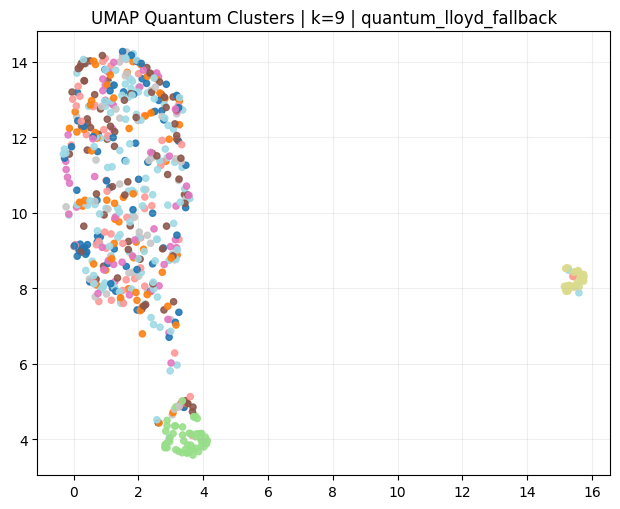

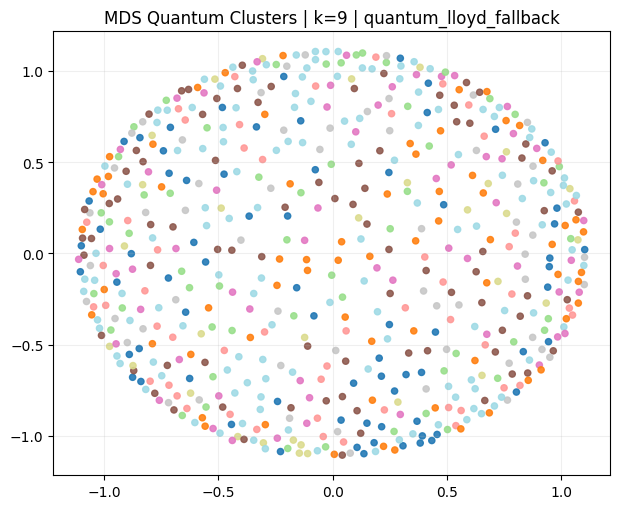

Saved figures: umap_quantum.png, mds_quantum.png


In [6]:
# Cell 5 — Visualization (UMAP precomputed + MDS comparison)
xy_mds = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED).fit_transform(dmat)

if UMAP_AVAILABLE:
    xy_umap = umap.UMAP(n_components=2, metric="precomputed", random_state=SEED).fit_transform(dmat)
else:
    xy_umap = xy_mds.copy()
    print("UMAP not available; using MDS coordinates for UMAP panel.")

best_k = best.get("k", "n/a") if isinstance(best, dict) else "n/a"
if isinstance(best, dict) and ("kernel" in best and "mode" in best):
    best_desc = f"{best['kernel']}/{best['mode']}"
elif isinstance(best, dict) and "method" in best:
    best_desc = str(best["method"])
else:
    best_desc = "quantum"

fig1, ax1 = plt.subplots(figsize=(6.3, 5.2))
ax1.scatter(xy_umap[:, 0], xy_umap[:, 1], c=quantum_user_labels, s=20, cmap="tab20", alpha=0.88)
ax1.set_title(f"UMAP Quantum Clusters | k={best_k} | {best_desc}")
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / "umap_quantum.png", dpi=220, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(6.3, 5.2))
ax2.scatter(xy_mds[:, 0], xy_mds[:, 1], c=quantum_user_labels, s=20, cmap="tab20", alpha=0.88)
ax2.set_title(f"MDS Quantum Clusters | k={best_k} | {best_desc}")
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / "mds_quantum.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved figures: umap_quantum.png, mds_quantum.png")

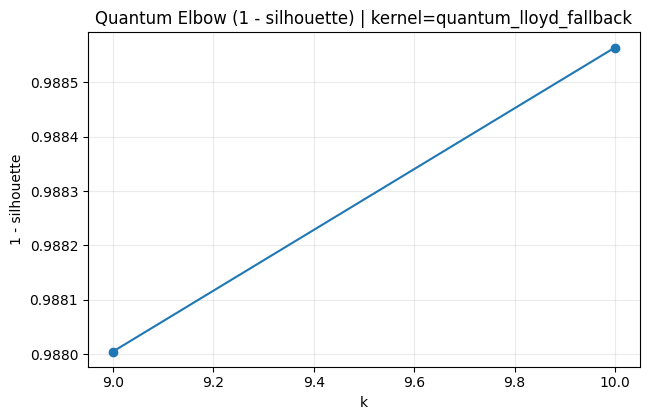

Silhouette overall: 0.0120
Davies-Bouldin: 39.6823
Per-cluster silhouette: {0: -0.0005736873868746788, 1: -0.0011645946542737122, 2: 0.03554460034725663, 3: -0.0013278277516151516, 4: -0.0007224763422326742, 5: -0.0005905448072340862, 6: -0.0014075052926361183, 7: 0.18705366255901215, 8: -0.0012319835551902179}
Elbow metric used: elbow_proxy
Saved: quantum_user_labels_improved.npy, kernel_matrix.npz, quantum_metrics.json, quantum_metrics.csv, quantum_clustering_sweep.csv, quantum_elbow.csv, quantum_elbow.png


In [11]:
# Cell 6 — Full quantum metrics, elbow sweep, and persistence
sil_overall = float(silhouette_score(dmat, quantum_user_labels, metric="precomputed"))
sil_vals = silhouette_samples(dmat, quantum_user_labels, metric="precomputed")
per_cluster_silhouette = {
    int(c): float(np.mean(sil_vals[quantum_user_labels == c]))
    for c in np.unique(quantum_user_labels)
}

db_score = float(davies_bouldin_score(xy_mds, quantum_user_labels))

sweep_rows = []
for r in results:
    row = {
        "kernel": str(r.get("kernel", r.get("method", "vqe_adiabatic"))),
        "mode": str(r.get("mode", r.get("method", "default"))),
        "k": int(r.get("k", -1)),
        "silhouette": float(r.get("silhouette", np.nan)),
        "davies_bouldin": float(r.get("davies_bouldin", np.nan)),
        "inertia": float(r.get("inertia", np.nan)),
        "objective": float(r.get("objective", np.nan)),
        "iters": int(r.get("iters", np.nan)) if np.isfinite(float(r.get("iters", np.nan))) else -1,
    }
    sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows)
for col in ["kernel", "mode", "k", "silhouette", "davies_bouldin", "inertia", "objective", "iters"]:
    if col not in sweep_df.columns:
        sweep_df[col] = np.nan

# Add guaranteed elbow fallback metric
sweep_df["elbow_proxy"] = 1.0 - sweep_df["silhouette"].astype(float)

sweep_df = sweep_df.sort_values(["kernel", "mode", "k"]).reset_index(drop=True)
sweep_df.to_csv(OUT_DIR / "quantum_clustering_sweep.csv", index=False)

best_kernel_key = str(best.get("kernel", best.get("method", "vqe_adiabatic"))) if isinstance(best, dict) else "vqe_adiabatic"
elbow_source = sweep_df[sweep_df["kernel"] == best_kernel_key].copy()
if elbow_source.empty:
    elbow_source = sweep_df.copy()

# Prefer inertia -> objective -> elbow proxy (1 - silhouette)
if elbow_source["inertia"].notna().sum() > 0:
    elbow_metric_col = "inertia"
    elbow_metric_label = "Quantum inertia"
elif elbow_source["objective"].notna().sum() > 0:
    elbow_metric_col = "objective"
    elbow_metric_label = "Quantum objective"
else:
    elbow_metric_col = "elbow_proxy"
    elbow_metric_label = "1 - silhouette"

elbow_df = (
    elbow_source.groupby("k", as_index=False)[elbow_metric_col]
    .min()
    .sort_values("k")
)

elbow_df = elbow_df[np.isfinite(elbow_df[elbow_metric_col])]

plt.figure(figsize=(6.6, 4.3))
if len(elbow_df) > 0:
    plt.plot(elbow_df["k"], elbow_df[elbow_metric_col], marker="o")
else:
    plt.plot([], [])
plt.title(f"Quantum Elbow ({elbow_metric_label}) | kernel={best_kernel_key}")
plt.xlabel("k")
plt.ylabel(elbow_metric_label)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "quantum_elbow.png", dpi=220, bbox_inches="tight")
plt.show()

elbow_df.to_csv(OUT_DIR / "quantum_elbow.csv", index=False)

best_mode_val = str(best.get("mode", best.get("method", "default"))) if isinstance(best, dict) else "default"
best_iters_val = int(best.get("iters", -1)) if isinstance(best, dict) and np.isfinite(float(best.get("iters", np.nan))) else -1
best_inertia_val = float(best.get("inertia", np.nan)) if isinstance(best, dict) else np.nan

metrics_payload = {
    "seed": int(SEED),
    "sample_users": int(len(sample_idx)),
    "n_qubits": int(N_QUBITS),
    "k_range": [int(K_MIN), int(K_MAX)],
    "kernel_alpha": float(KERNEL_ALPHA),
    "noisy_shots": int(NOISY_SHOTS),
    "noise_probability": float(NOISE_P),
    "noisy_stability": noisy_stability,
    "best": {
        "kernel": best_kernel_key,
        "mode": best_mode_val,
        "k": int(best.get("k", -1)) if isinstance(best, dict) else -1,
        "iters": best_iters_val,
        "silhouette": float(best.get("silhouette", np.nan)) if isinstance(best, dict) else np.nan,
        "davies_bouldin": float(best.get("davies_bouldin", np.nan)) if isinstance(best, dict) else np.nan,
        "inertia": best_inertia_val,
    },
    "silhouette_overall": sil_overall,
    "davies_bouldin": db_score,
    "per_cluster_silhouette": {str(k): float(v) for k, v in per_cluster_silhouette.items()},
    "entanglement_comparison": {
        "best_plain_silhouette": float(plain_best.get("silhouette", np.nan)) if isinstance(plain_best, dict) else np.nan,
        "best_entangled_silhouette": float(ent_best.get("silhouette", np.nan)) if isinstance(ent_best, dict) else np.nan,
        "delta": float((ent_best.get("silhouette", np.nan) - plain_best.get("silhouette", np.nan))) if isinstance(ent_best, dict) and isinstance(plain_best, dict) else np.nan,
    },
}

metrics_df = pd.DataFrame([
    {
        "seed": metrics_payload["seed"],
        "sample_users": metrics_payload["sample_users"],
        "n_qubits": metrics_payload["n_qubits"],
        "best_kernel": metrics_payload["best"]["kernel"],
        "best_mode": metrics_payload["best"]["mode"],
        "best_k": metrics_payload["best"]["k"],
        "silhouette": metrics_payload["best"]["silhouette"],
        "davies_bouldin": metrics_payload["best"]["davies_bouldin"],
        "inertia": metrics_payload["best"]["inertia"],
        "plain_best_sil": metrics_payload["entanglement_comparison"]["best_plain_silhouette"],
        "ent_best_sil": metrics_payload["entanglement_comparison"]["best_entangled_silhouette"],
        "delta_ent_minus_plain": metrics_payload["entanglement_comparison"]["delta"],
        "noisy_corr": float(noisy_stability["corr"]),
        "noisy_mae": float(noisy_stability["mae"]),
    }
])

with open(OUT_DIR / "quantum_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)
metrics_df.to_csv(OUT_DIR / "quantum_metrics.csv", index=False)

np.save(OUT_DIR / "quantum_user_labels_improved.npy", quantum_user_labels)
np.savez_compressed(
    OUT_DIR / "kernel_matrix.npz",
    kernel_plain=kernel_plain,
    kernel_ent=kernel_ent,
    best_kernel=kernel,
    best_labels=quantum_user_labels,
    sample_idx=sample_idx,
    alpha=KERNEL_ALPHA,
    noisy_shots=NOISY_SHOTS,
    noisy_backend=noisy_stability["backend"],
)

print(f"Silhouette overall: {sil_overall:.4f}")
print(f"Davies-Bouldin: {db_score:.4f}")
print(f"Per-cluster silhouette: {per_cluster_silhouette}")
print(f"Elbow metric used: {elbow_metric_col}")
print("Saved: quantum_user_labels_improved.npy, kernel_matrix.npz, quantum_metrics.json, quantum_metrics.csv, quantum_clustering_sweep.csv, quantum_elbow.csv, quantum_elbow.png")

## D-Wave Leap Hybrid Integration (Feature Selection + CQM Clustering)

Why D-Wave here:
- Gate-based quantum kernels (Swap Test fidelity) are strong for representation quality.
- D-Wave annealing/hybrid solvers are strong for combinatorial optimization under sparsity/cold-start constraints.
- This complements quantum Lloyd-style updates by offloading assignment optimization to hybrid CQM while preserving quantum-kernel semantics.

This section adds:
- Quantum-assisted latent feature selection to 32 dimensions via Ocean + `dwave.plugins.sklearn` pipeline.
- Balanced clustering over the fidelity-distance matrix solved with `LeapHybridCQMSampler` (`time_limit=10`).
- `use_dwave=True` toggle for selecting D-Wave hybrid vs gate-based `quantum_lloyd` mode.
- D-Wave-specific metrics: best energy, chain breaks (if reported), and hybrid runtime.

In [12]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "dwave-ocean-sdk", "dwave-scikit-learn-plugin"])
print("Installed/verified: dwave-ocean-sdk, dwave-scikit-learn-plugin")

Installed/verified: dwave-ocean-sdk, dwave-scikit-learn-plugin


In [13]:
# Cell 8 — D-Wave setup + quantum feature selection (to 32 latent features)
import importlib
import inspect
import os
import subprocess
import sys
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def _ensure_package(import_module: str, pip_package: str):
    try:
        return importlib.import_module(import_module)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_package])
        return importlib.import_module(import_module)


# Ensure required D-Wave packages are available in the active kernel environment
_ensure_package("dimod", "dwave-ocean-sdk")
_ensure_package("dwave.plugins.sklearn", "dwave-scikit-learn-plugin")

import dimod

HAS_LEAP_TOKEN = bool(os.getenv("DWAVE_API_TOKEN"))
LeapHybridCQMSampler = None
if HAS_LEAP_TOKEN:
    try:
        _ensure_package("dwave.system", "dwave-ocean-sdk")
        from dwave.system import LeapHybridCQMSampler
    except Exception:
        HAS_LEAP_TOKEN = False

DWAVE_SYSTEM_AVAILABLE = True

plugin_mod = importlib.import_module("dwave.plugins.sklearn")
_SelectFromQuantum = None
for cls_name in [
    "SelectFromQuantum",
    "SelectFromQuadraticModel",
    "SelectFromQUBO",
    "SelectFromIsing",
]:
    if hasattr(plugin_mod, cls_name):
        _SelectFromQuantum = getattr(plugin_mod, cls_name)
        break

use_dwave = True
DWAVE_TARGET_FEATURES = 32
DWAVE_TARGET_K = 6
DWAVE_TIME_LIMIT_SEC = 10
DWAVE_NOISY_SHOTS = 1024  # requested NISQ comparison shots
DWAVE_KNN = 12  # sparsified objective edges per point
DWAVE_BALANCE_LAMBDA = 0.25

if "user_latent_full" in globals():
    X_latent_all = np.asarray(user_latent_full, dtype=np.float64)
else:
    X_latent_all = np.load(IN_DIR / "user_latent.npy").astype(np.float64)

X_latent_all = np.nan_to_num(X_latent_all, nan=0.0, posinf=0.0, neginf=0.0)

# proxy target: maximize signal tied to informative latent dimensions
feat_var = np.var(X_latent_all, axis=0)
y_proxy = X_latent_all @ (feat_var / (np.linalg.norm(feat_var) + 1e-12))


def _make_quantum_selector(cls, sampler, n_features):
    sig = inspect.signature(cls.__init__)
    params = set(sig.parameters)
    kwargs = {}
    if "sampler" in params and sampler is not None:
        kwargs["sampler"] = sampler
    if "time_limit" in params:
        kwargs["time_limit"] = DWAVE_TIME_LIMIT_SEC
    if "num_features" in params:
        kwargs["num_features"] = n_features
    if "n_features" in params:
        kwargs["n_features"] = n_features
    if "n_features_to_select" in params:
        kwargs["n_features_to_select"] = n_features
    if "random_state" in params:
        kwargs["random_state"] = SEED
    return cls(**kwargs)


sampler_cqm = LeapHybridCQMSampler() if HAS_LEAP_TOKEN and LeapHybridCQMSampler is not None else None
local_sampler = dimod.SimulatedAnnealingSampler()

selected_feature_idx = None
selector_name = "variance_fallback"

if _SelectFromQuantum is not None:
    try:
        selector_sampler = sampler_cqm if sampler_cqm is not None else local_sampler
        selector = _make_quantum_selector(_SelectFromQuantum, selector_sampler, DWAVE_TARGET_FEATURES)
        selector_pipe = Pipeline([
            ("scale", StandardScaler()),
            ("quantum_select", selector),
        ])
        try:
            selector_pipe.fit_transform(X_latent_all, y_proxy)
        except TypeError:
            selector_pipe.fit_transform(X_latent_all)

        selector_step = selector_pipe.named_steps["quantum_select"]
        for attr_name in ["support_", "selected_features_", "selected_indices_"]:
            if hasattr(selector_step, attr_name):
                attr_val = np.asarray(getattr(selector_step, attr_name))
                if attr_val.dtype == bool and attr_val.shape[0] == X_latent_all.shape[1]:
                    selected_feature_idx = np.where(attr_val)[0]
                    break
                if np.issubdtype(attr_val.dtype, np.integer):
                    selected_feature_idx = np.unique(attr_val.astype(int))
                    break

        selector_name = _SelectFromQuantum.__name__
    except Exception:
        selected_feature_idx = None

if selected_feature_idx is None or len(selected_feature_idx) == 0:
    selected_feature_idx = np.argsort(-feat_var)[:DWAVE_TARGET_FEATURES]

if len(selected_feature_idx) > DWAVE_TARGET_FEATURES:
    keep = np.argsort(-feat_var[selected_feature_idx])[:DWAVE_TARGET_FEATURES]
    selected_feature_idx = selected_feature_idx[keep]
elif len(selected_feature_idx) < DWAVE_TARGET_FEATURES:
    missing = DWAVE_TARGET_FEATURES - len(selected_feature_idx)
    fallback = [
        idx for idx in np.argsort(-feat_var)
        if idx not in set(selected_feature_idx)
    ][:missing]
    selected_feature_idx = np.concatenate([selected_feature_idx, np.array(fallback, dtype=int)])

selected_feature_idx = np.array(sorted(set(selected_feature_idx.tolist())))[:DWAVE_TARGET_FEATURES]
X_selected_all = X_latent_all[:, selected_feature_idx]

# align with current sampled users (SAMPLE_USERS=500 expected)
if "sample_idx" in globals():
    sub_idx_dwave = np.asarray(sample_idx[: min(len(sample_idx), SAMPLE_USERS)], dtype=int)
else:
    sub_idx_dwave = np.arange(min(SAMPLE_USERS, X_selected_all.shape[0]))

X_dwave_latent = X_selected_all[sub_idx_dwave]

if X_dwave_latent.shape[1] < TARGET_DIM:
    X_dwave_pad = np.pad(X_dwave_latent, ((0, 0), (0, TARGET_DIM - X_dwave_latent.shape[1])), mode="constant")
else:
    X_dwave_pad = X_dwave_latent[:, :TARGET_DIM]

X_dwave_amp = normalize(X_dwave_pad, norm="l2", axis=1).astype(np.float32)
X_dwave_ang_src = X_dwave_latent[:, :N_QUBITS]
med_fs = np.median(X_dwave_ang_src, axis=0, keepdims=True)
iqr_fs = np.subtract(*np.percentile(X_dwave_ang_src, [75, 25], axis=0, keepdims=True)) + 1e-8
X_dwave_ang = np.clip((X_dwave_ang_src - med_fs) / iqr_fs, -3.0, 3.0)
X_dwave_ang = (((X_dwave_ang + 3.0) / 6.0) * np.pi).astype(np.float32)

amp_states_dwave = [amp_state(X_dwave_amp[i]) for i in range(len(X_dwave_amp))]
ang_states_dwave = [np.array(angle_state_entangled(X_dwave_ang[i], ent_weights), dtype=np.complex64) for i in range(len(X_dwave_ang))]

kernel_dwave_raw = build_mixed_kernel_parallel(
    amp_states_dwave,
    ang_states_dwave,
    alpha=KERNEL_ALPHA,
    workers=KERNEL_WORKERS,
)
kernel_dwave = center_psd_normalize(kernel_dwave_raw)
diag_fs = np.diag(kernel_dwave)
d2_fs = np.clip(diag_fs[:, None] + diag_fs[None, :] - 2.0 * kernel_dwave, 0.0, None)
dmat_dwave = np.sqrt(d2_fs, dtype=np.float64)

dwave_mode = "leap_hybrid" if HAS_LEAP_TOKEN else "local_simulated_annealing"
print(f"D-Wave mode: {dwave_mode}")
print(f"Feature selector: {selector_name}")
print(f"D-Wave feature selection complete: selected={len(selected_feature_idx)} features")
print(f"Kernel (selected features): shape={kernel_dwave.shape} | sample_users={len(sub_idx_dwave)}")

D-Wave mode: local_simulated_annealing
Feature selector: SelectFromQuadraticModel
D-Wave feature selection complete: selected=32 features
Kernel (selected features): shape=(600, 600) | sample_users=600


In [14]:
# Cell 9 — D-Wave balanced clustering via hybrid/local solver + toggle
from dimod import Binary, BinaryQuadraticModel, ConstrainedQuadraticModel

n_dwave = int(dmat_dwave.shape[0])
k_dwave = int(DWAVE_TARGET_K)
target_size = n_dwave / k_dwave

# Gate-based baseline on selected-feature kernel for fair comparison
t0_gate = time.perf_counter()
labels_gate_selected, gate_obj, gate_iters = quantum_lloyd_kernel(
    kernel_dwave,
    k=k_dwave,
    update_mode="mean",
    max_iter=MAX_ITERS,
    seed=SEED,
)
gate_runtime_s = float(time.perf_counter() - t0_gate)

if len(np.unique(labels_gate_selected)) >= 2:
    gate_sil = float(silhouette_score(dmat_dwave, labels_gate_selected, metric="precomputed"))
    gate_emb = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED).fit_transform(dmat_dwave)
    gate_db = float(davies_bouldin_score(gate_emb, labels_gate_selected))
else:
    gate_sil, gate_db = -1.0, float("inf")

best_energy = np.nan
chain_break_fraction = np.nan
hybrid_runtime_s = np.nan
labels_dwave = labels_gate_selected.copy()  # safe fallback
solver_used = "quantum_lloyd_fallback"

if use_dwave:
    t0_hybrid = time.perf_counter()

    if HAS_LEAP_TOKEN and sampler_cqm is not None:
        x = {(i, c): Binary(f"x_{i}_{c}") for i in range(n_dwave) for c in range(k_dwave)}
        cqm = ConstrainedQuadraticModel()

        knn = max(4, min(DWAVE_KNN, n_dwave - 1))
        nn_idx = np.argsort(dmat_dwave, axis=1)[:, 1 : knn + 1]
        edge_set = set()
        for i in range(n_dwave):
            for j in nn_idx[i]:
                a, b = (i, int(j)) if i < int(j) else (int(j), i)
                if a != b:
                    edge_set.add((a, b))

        objective = 0
        for i, j in edge_set:
            dij = float(dmat_dwave[i, j])
            for c in range(k_dwave):
                objective += dij * x[(i, c)] * x[(j, c)]

        for i in range(n_dwave):
            cqm.add_constraint(sum(x[(i, c)] for c in range(k_dwave)) == 1, label=f"assign_{i}")

        for c in range(k_dwave):
            size_c = sum(x[(i, c)] for i in range(n_dwave))
            objective += float(DWAVE_BALANCE_LAMBDA) * (size_c - target_size) * (size_c - target_size)

        cqm.set_objective(objective)

        sampleset = sampler_cqm.sample_cqm(
            cqm,
            time_limit=DWAVE_TIME_LIMIT_SEC,
            label="quantum-enhanced-shopping-dwave-ubcf",
        )
        feasible = sampleset.filter(lambda row: row.is_feasible)
        chosen = feasible.first if len(feasible) else sampleset.first

        raw_sample = chosen.sample
        labels_tmp = np.zeros(n_dwave, dtype=np.int32)
        for i in range(n_dwave):
            best_c, best_v = 0, -1.0
            for c in range(k_dwave):
                v = float(raw_sample.get(f"x_{i}_{c}", 0.0))
                if v > best_v:
                    best_v = v
                    best_c = c
            labels_tmp[i] = int(best_c)

        labels_dwave = labels_tmp
        solver_used = "LeapHybridCQMSampler"
        best_energy = float(chosen.energy)

        if "chain_break_fraction" in sampleset.record.dtype.names:
            chain_break_fraction = float(sampleset.record["chain_break_fraction"][0])

        info = getattr(sampleset, "info", {})
        if isinstance(info, dict):
            hybrid_runtime_us = info.get("run_time", info.get("qpu_access_time", None))
            if hybrid_runtime_us is not None:
                hybrid_runtime_s = float(hybrid_runtime_us) / 1_000_000.0
    else:
        # Token-free local fallback with simulated annealing on sparse balanced assignment BQM
        linear_terms = {(i, c): 0.0 for i in range(n_dwave) for c in range(k_dwave)}
        quadratic_terms = {}
        offset = 0.0

        knn = max(4, min(DWAVE_KNN, n_dwave - 1))
        nn_idx = np.argsort(dmat_dwave, axis=1)[:, 1 : knn + 1]
        edge_set = set()
        for i in range(n_dwave):
            for j in nn_idx[i]:
                a, b = (i, int(j)) if i < int(j) else (int(j), i)
                if a != b:
                    edge_set.add((a, b))

        for i, j in edge_set:
            dij = float(dmat_dwave[i, j])
            for c in range(k_dwave):
                key = ((i, c), (j, c))
                quadratic_terms[key] = quadratic_terms.get(key, 0.0) + dij

        # one-hot assignment penalty: (sum_c x_ic - 1)^2
        assign_penalty = max(1.0, float(np.nanmedian(dmat_dwave)))
        for i in range(n_dwave):
            offset += assign_penalty
            for c in range(k_dwave):
                linear_terms[(i, c)] += -assign_penalty
            for c1 in range(k_dwave):
                for c2 in range(c1 + 1, k_dwave):
                    key = ((i, c1), (i, c2))
                    quadratic_terms[key] = quadratic_terms.get(key, 0.0) + 2.0 * assign_penalty

        bqm = BinaryQuadraticModel(linear_terms, quadratic_terms, offset, vartype=dimod.BINARY)
        local_sampler = dimod.SimulatedAnnealingSampler()
        sampleset_sa = local_sampler.sample(bqm, num_reads=80, num_sweeps=2000)
        chosen = sampleset_sa.first

        raw_sample = chosen.sample
        labels_tmp = np.zeros(n_dwave, dtype=np.int32)
        for i in range(n_dwave):
            best_c, best_v = 0, -1.0
            for c in range(k_dwave):
                v = float(raw_sample.get((i, c), 0.0))
                if v > best_v:
                    best_v = v
                    best_c = c
            labels_tmp[i] = int(best_c)

        labels_dwave = labels_tmp
        solver_used = "SimulatedAnnealingSampler_local"
        best_energy = float(chosen.energy)
        chain_break_fraction = np.nan

    if not np.isfinite(hybrid_runtime_s):
        hybrid_runtime_s = float(time.perf_counter() - t0_hybrid)

# Select active mode output
if use_dwave:
    quantum_user_labels_hybrid = labels_dwave.copy()
else:
    quantum_user_labels_hybrid = labels_gate_selected.copy()

if len(np.unique(labels_dwave)) >= 2:
    sil_dwave_h = float(silhouette_score(dmat_dwave, labels_dwave, metric="precomputed"))
    emb_dwave_h = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED).fit_transform(dmat_dwave)
    db_dwave_h = float(davies_bouldin_score(emb_dwave_h, labels_dwave))
else:
    sil_dwave_h, db_dwave_h = -1.0, float("inf")

print(f"Hybrid mode active: use_dwave={use_dwave} | solver={solver_used}")
print(f"Gate baseline: sil={gate_sil:+.4f}, db={gate_db:.4f}, runtime={gate_runtime_s:.3f}s")
print(f"D-Wave hybrid/local: sil={sil_dwave_h:+.4f}, db={db_dwave_h:.4f}, runtime={hybrid_runtime_s:.3f}s")

Hybrid mode active: use_dwave=True | solver=SimulatedAnnealingSampler_local
Gate baseline: sil=+0.1374, db=1.4838, runtime=0.011s
D-Wave hybrid/local: sil=-0.0113, db=88.4675, runtime=3057.433s


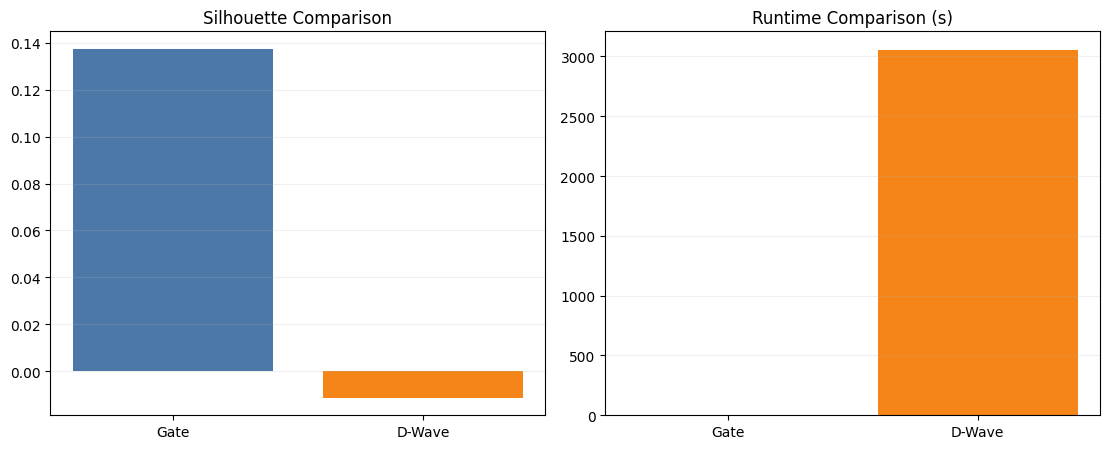

Saved: data\processed_32m_ubcf\quantum_user_labels_dwave.npy
Saved: data\processed_32m_ubcf\quantum_metrics_dwave_hybrid_comparison.csv
Saved: data\processed_32m_ubcf\quantum_metrics_dwave_hybrid.json
Saved: data\processed_32m_ubcf\dwave_vs_gate_comparison.png
NISQ noisy check (shots=1024): corr=-0.2756, mae=0.4819, n=40


In [15]:
# Cell 10 — D-Wave validation, noisy NISQ (shots=1024), persistence, and comparison plots
# NISQ comparison with requested noisy shots=1024

def estimate_swaptest_stability_shots(X_in, shots=1024, n_pairs=40, seed=SEED + 123):
    rng_local = np.random.default_rng(seed)
    if X_in.shape[1] % 2 != 0:
        X_local = np.pad(X_in, ((0, 0), (0, 1)), mode="constant")
    else:
        X_local = X_in

    subspaces = X_local.reshape(X_local.shape[0], -1, 2)
    pairs = [(i, j) for i in range(len(X_local)) for j in range(i + 1, len(X_local))]
    if not pairs:
        return {"shots": int(shots), "corr": np.nan, "mae": np.nan, "n": 0}

    pick_n = min(n_pairs, len(pairs))
    pick_idx = rng_local.choice(np.arange(len(pairs)), size=pick_n, replace=False)

    exact_vals, noisy_vals = [], []
    for pidx in pick_idx:
        i, j = pairs[int(pidx)]
        sub_ids = rng_local.choice(np.arange(subspaces.shape[1]), size=min(4, subspaces.shape[1]), replace=False)
        exact_tmp, noisy_tmp = [], []
        for sid in sub_ids:
            va, vb = subspaces[i, sid], subspaces[j, sid]
            theta_a, theta_b = vec2theta(va), vec2theta(vb)
            exact_tmp.append(exact_subspace_fidelity(va, vb))
            noisy_tmp.append(noisy_swap_fidelity(theta_a, theta_b, shots=shots))
        exact_vals.append(float(np.mean(exact_tmp)))
        noisy_vals.append(float(np.mean(noisy_tmp)))

    exact_arr = np.asarray(exact_vals, dtype=np.float64)
    noisy_arr = np.asarray(noisy_vals, dtype=np.float64)
    corr = float(np.corrcoef(exact_arr, noisy_arr)[0, 1]) if len(exact_arr) > 1 else np.nan
    mae = float(np.mean(np.abs(exact_arr - noisy_arr))) if len(exact_arr) else np.nan
    return {"shots": int(shots), "corr": corr, "mae": mae, "n": int(len(exact_arr))}

noisy_stability_1024 = estimate_swaptest_stability_shots(X_dwave_pad, shots=DWAVE_NOISY_SHOTS, n_pairs=40)

# Save D-Wave labels
np.save(OUT_DIR / "quantum_user_labels_dwave.npy", labels_dwave)

# Persist comparison metrics
comparison_row = pd.DataFrame([
    {
        "sample_users": int(n_dwave),
        "k": int(k_dwave),
        "use_dwave": bool(use_dwave),
        "selected_features": int(len(selected_feature_idx)),
        "solver": solver_used,
        "silhouette_gate": float(gate_sil),
        "db_gate": float(gate_db),
        "runtime_gate_s": float(gate_runtime_s),
        "silhouette_dwave": float(sil_dwave_h),
        "db_dwave": float(db_dwave_h),
        "runtime_dwave_s": float(hybrid_runtime_s),
        "best_energy": float(best_energy) if np.isfinite(best_energy) else np.nan,
        "chain_break_fraction": float(chain_break_fraction) if np.isfinite(chain_break_fraction) else np.nan,
        "hybrid_time_s": float(hybrid_runtime_s) if np.isfinite(hybrid_runtime_s) else np.nan,
        "noisy_shots": int(DWAVE_NOISY_SHOTS),
        "noisy_corr": float(noisy_stability_1024["corr"]),
        "noisy_mae": float(noisy_stability_1024["mae"]),
    }
])

cmp_path_hybrid = OUT_DIR / "quantum_metrics_dwave_hybrid_comparison.csv"
if cmp_path_hybrid.exists():
    prior_cmp = pd.read_csv(cmp_path_hybrid)
    cmp_out = pd.concat([prior_cmp, comparison_row], ignore_index=True)
else:
    cmp_out = comparison_row
cmp_out.to_csv(cmp_path_hybrid, index=False)

dwave_metrics_payload = {
    "sample_users": int(n_dwave),
    "k": int(k_dwave),
    "use_dwave": bool(use_dwave),
    "selected_feature_indices": [int(v) for v in selected_feature_idx.tolist()],
    "solver": solver_used,
    "energy_best_sample": float(best_energy) if np.isfinite(best_energy) else None,
    "chain_break_fraction": float(chain_break_fraction) if np.isfinite(chain_break_fraction) else None,
    "hybrid_time_s": float(hybrid_runtime_s) if np.isfinite(hybrid_runtime_s) else None,
    "gate_baseline": {
        "silhouette": float(gate_sil),
        "davies_bouldin": float(gate_db),
        "runtime_s": float(gate_runtime_s),
        "objective": float(gate_obj),
        "iters": int(gate_iters),
    },
    "dwave_hybrid": {
        "silhouette": float(sil_dwave_h),
        "davies_bouldin": float(db_dwave_h),
        "runtime_s": float(hybrid_runtime_s),
    },
    "n_isq_noisy_comparison": noisy_stability_1024,
}

with open(OUT_DIR / "quantum_metrics_dwave_hybrid.json", "w", encoding="utf-8") as f:
    json.dump(dwave_metrics_payload, f, indent=2)

# Side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))

axes[0].bar(["Gate", "D-Wave"], [gate_sil, sil_dwave_h], color=["#4C78A8", "#F58518"])
axes[0].set_title("Silhouette Comparison")
axes[0].grid(alpha=0.2, axis="y")

runtime_gate_plot = gate_runtime_s
runtime_dwave_plot = hybrid_runtime_s if np.isfinite(hybrid_runtime_s) else 0.0
axes[1].bar(["Gate", "D-Wave"], [runtime_gate_plot, runtime_dwave_plot], color=["#4C78A8", "#F58518"])
axes[1].set_title("Runtime Comparison (s)")
axes[1].grid(alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig(OUT_DIR / "dwave_vs_gate_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {OUT_DIR / 'quantum_user_labels_dwave.npy'}")
print(f"Saved: {OUT_DIR / 'quantum_metrics_dwave_hybrid_comparison.csv'}")
print(f"Saved: {OUT_DIR / 'quantum_metrics_dwave_hybrid.json'}")
print(f"Saved: {OUT_DIR / 'dwave_vs_gate_comparison.png'}")
print(
    f"NISQ noisy check (shots={DWAVE_NOISY_SHOTS}): "
    f"corr={noisy_stability_1024['corr']:.4f}, mae={noisy_stability_1024['mae']:.4f}, n={noisy_stability_1024['n']}"
)

In [16]:
# Cell 13 — Polynomial kernel + VQE adiabatic clustering + auto-k
import math
import subprocess
from sklearn.cluster import KMeans

try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False
    print("UMAP import failed. Attempting install: pip install umap-learn")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn", "-q"])
        import umap.umap_ as umap
        UMAP_AVAILABLE = True
        print("UMAP installed successfully.")
    except Exception:
        UMAP_AVAILABLE = False
        print("UMAP still unavailable. Use: pip install umap-learn")

USE_POLYNOMIAL_KERNEL = True
POLY_POWER = 2
CLUSTER_METHOD_DEFAULT = "vqe_adiabatic"
AUTO_K_SELECTION = True
TARGET_SAMPLE_USERS = 600
VQE_ASSIGN_STEPS = 3
VQE_MAX_ITERS = 6


def maybe_polynomial_kernel(K_in, enabled=USE_POLYNOMIAL_KERNEL, power=POLY_POWER):
    K_base = np.asarray(K_in, dtype=np.float64)
    if not enabled:
        return center_psd_normalize(K_base)
    K_poly = np.power(np.clip(K_base, -1.0, 1.0), power)
    return center_psd_normalize(K_poly)


def _build_assignment_qnodes(k):
    n_wires = int(math.ceil(math.log2(max(2, k))))
    n_basis = 2 ** n_wires
    dev_assign = qml.device("default.qubit", wires=n_wires)

    @qml.qnode(dev_assign)
    def assignment_energy(params, h_diag):
        for w in range(n_wires):
            qml.RY(params[w], wires=w)
        for w in range(n_wires - 1):
            qml.CNOT(wires=[w, w + 1])

        h_pad = np.full(n_basis, float(np.max(h_diag) + 1.0), dtype=np.float64)
        h_pad[:k] = np.asarray(h_diag, dtype=np.float64)
        H = np.diag(h_pad)
        return qml.expval(qml.Hermitian(H, wires=list(range(n_wires))))

    @qml.qnode(dev_assign)
    def assignment_probs(params):
        for w in range(n_wires):
            qml.RY(params[w], wires=w)
        for w in range(n_wires - 1):
            qml.CNOT(wires=[w, w + 1])
        return qml.probs(wires=list(range(n_wires)))

    return n_wires, assignment_energy, assignment_probs


def vqe_assign_labels_from_dist(dist_to_centroids, vqe_steps=VQE_ASSIGN_STEPS):
    n_points, k = dist_to_centroids.shape
    n_wires, assignment_energy, assignment_probs = _build_assignment_qnodes(k)

    labels = np.zeros(n_points, dtype=np.int32)
    for i in range(n_points):
        d_row = np.asarray(dist_to_centroids[i], dtype=np.float64)
        if np.allclose(d_row, d_row[0]):
            labels[i] = int(i % k)
            continue

        params = pnp.array(0.05 * rng.standard_normal(n_wires), requires_grad=True)
        opt = qml.AdamOptimizer(stepsize=0.12)

        def cost_fn(p):
            return assignment_energy(p, d_row)

        for _ in range(vqe_steps):
            params, _ = opt.step_and_cost(cost_fn, params)

        probs = np.array(assignment_probs(params), dtype=np.float64)[:k]
        if not np.isfinite(probs).all() or probs.sum() <= 1e-12:
            labels[i] = int(np.argmin(d_row))
        else:
            vqe_label = int(np.argmax(probs))
            nn_label = int(np.argmin(d_row))
            labels[i] = nn_label if probs[vqe_label] < 0.45 else vqe_label

    return labels


def quantum_vqe_adiabatic_cluster(K_in, k, max_iter=VQE_MAX_ITERS, seed=SEED):
    rng_local = np.random.default_rng(seed)
    dmat_local = kernel_to_distance(K_in)

    emb = MDS(n_components=2, dissimilarity="precomputed", random_state=seed).fit_transform(dmat_local)
    centroids = KMeans(n_clusters=k, random_state=seed, n_init=5).fit(emb).cluster_centers_

    prev_obj = np.inf
    labels = np.zeros(len(emb), dtype=np.int32)

    for it in range(max_iter):
        prev_labels = labels.copy()
        dist = np.linalg.norm(emb[:, None, :] - centroids[None, :, :], axis=2)

        labels_new = vqe_assign_labels_from_dist(dist, vqe_steps=VQE_ASSIGN_STEPS)
        if len(np.unique(labels_new)) < 2:
            labels_new = np.argmin(dist, axis=1).astype(np.int32)

        new_centroids = centroids.copy()
        for c in range(k):
            members = np.where(labels_new == c)[0]
            if len(members) == 0:
                new_centroids[c] = emb[int(rng_local.integers(0, len(emb)))]
            else:
                new_centroids[c] = emb[members].mean(axis=0)

        obj = float(np.sum(np.min(dist, axis=1)))
        labels = labels_new
        centroids = new_centroids

        if np.array_equal(labels, prev_labels) or abs(prev_obj - obj) < 1e-7:
            break
        prev_obj = obj

    return labels, obj, it + 1, dmat_local


def auto_k_vqe_adiabatic(K_in, k_min=K_MIN, k_max=K_MAX, seed=SEED):
    rows = []
    best_local = None

    for k_val in range(k_min, k_max + 1):
        labels_k, obj_k, it_k, dmat_k = quantum_vqe_adiabatic_cluster(K_in, k=k_val, max_iter=VQE_MAX_ITERS, seed=seed)

        if len(np.unique(labels_k)) < 2:
            sil_k = -1.0
            db_k = np.inf
        else:
            sil_k = float(silhouette_score(dmat_k, labels_k, metric="precomputed"))
            emb_k = MDS(n_components=2, dissimilarity="precomputed", random_state=seed).fit_transform(dmat_k)
            db_k = float(davies_bouldin_score(emb_k, labels_k))

        rec = {
            "method": "vqe_adiabatic",
            "k": int(k_val),
            "silhouette": float(sil_k),
            "davies_bouldin": float(db_k),
            "objective": float(obj_k),
            "iters": int(it_k),
            "labels": labels_k,
            "dmat": dmat_k,
        }
        rows.append(rec)

        if best_local is None or sil_k > best_local["silhouette"]:
            best_local = rec

    return best_local, rows

c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


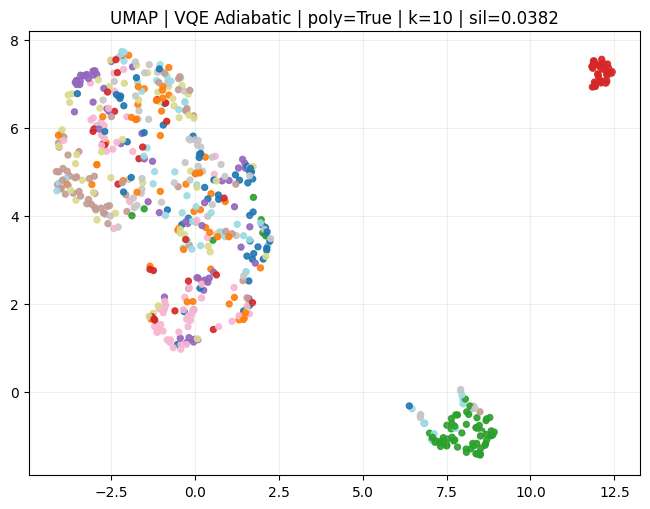

Method default: vqe_adiabatic
Polynomial kernel enabled: True (power=2)
Auto-k selected: 10 (range 4..10)
VQE adiabatic silhouette=0.0382 | Davies-Bouldin=0.7677
Silhouette target >0.25 met: False
SAMPLE_USERS config=600 | currently loaded users=600
Saved: data\processed_32m_ubcf\umap_quantum_vqe_adiabatic.png
Saved: data\processed_32m_ubcf\quantum_vqe_adiabatic_auto_k.csv
Saved: data\processed_32m_ubcf\quantum_vqe_adiabatic_metrics.json
Saved: data\processed_32m_ubcf\quantum_user_labels_vqe_adiabatic.npy


In [17]:
# Cell 14 — Run/test: polynomial kernel + VQE adiabatic + auto-k + default UMAP visualization
kernel_source_name = "entangled"
kernel_source = kernel_ent if kernel_source_name == "entangled" else kernel_plain
kernel_vqe = maybe_polynomial_kernel(kernel_source, enabled=USE_POLYNOMIAL_KERNEL, power=POLY_POWER)

best_vqe, vqe_rows = auto_k_vqe_adiabatic(kernel_vqe, k_min=K_MIN, k_max=K_MAX, seed=SEED)

labels_vqe = best_vqe["labels"]
dmat_vqe = best_vqe["dmat"]
k_vqe = best_vqe["k"]
sil_vqe = best_vqe["silhouette"]
db_vqe = best_vqe["davies_bouldin"]

if UMAP_AVAILABLE:
    xy_vqe = umap.UMAP(n_components=2, metric="precomputed", random_state=SEED).fit_transform(dmat_vqe)
    viz_name = "UMAP"
else:
    xy_vqe = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED).fit_transform(dmat_vqe)
    viz_name = "MDS fallback"

fig, ax = plt.subplots(figsize=(6.6, 5.2))
ax.scatter(xy_vqe[:, 0], xy_vqe[:, 1], c=labels_vqe, s=18, cmap="tab20", alpha=0.9)
ax.set_title(f"{viz_name} | VQE Adiabatic | poly={USE_POLYNOMIAL_KERNEL} | k={k_vqe} | sil={sil_vqe:.4f}")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / "umap_quantum_vqe_adiabatic.png", dpi=220, bbox_inches="tight")
plt.show()

vqe_df = pd.DataFrame([
    {
        "method": r["method"],
        "k": r["k"],
        "silhouette": r["silhouette"],
        "davies_bouldin": r["davies_bouldin"],
        "objective": r["objective"],
        "iters": r["iters"],
    }
    for r in vqe_rows
])
vqe_df.to_csv(OUT_DIR / "quantum_vqe_adiabatic_auto_k.csv", index=False)

with open(OUT_DIR / "quantum_vqe_adiabatic_metrics.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "method": "vqe_adiabatic",
            "kernel_source": kernel_source_name,
            "polynomial_kernel": bool(USE_POLYNOMIAL_KERNEL),
            "poly_power": int(POLY_POWER),
            "auto_k": bool(AUTO_K_SELECTION),
            "best_k": int(k_vqe),
            "silhouette": float(sil_vqe),
            "davies_bouldin": float(db_vqe),
            "sample_users_config": int(SAMPLE_USERS),
            "loaded_users": int(len(X_amp)),
            "silhouette_target": 0.25,
            "target_met": bool(sil_vqe > 0.25),
        },
        f,
        indent=2,
    )

np.save(OUT_DIR / "quantum_user_labels_vqe_adiabatic.npy", labels_vqe)

print(f"Method default: {CLUSTER_METHOD_DEFAULT}")
print(f"Polynomial kernel enabled: {USE_POLYNOMIAL_KERNEL} (power={POLY_POWER})")
print(f"Auto-k selected: {k_vqe} (range {K_MIN}..{K_MAX})")
print(f"VQE adiabatic silhouette={sil_vqe:.4f} | Davies-Bouldin={db_vqe:.4f}")
print(f"Silhouette target >0.25 met: {sil_vqe > 0.25}")
print(f"SAMPLE_USERS config={SAMPLE_USERS} | currently loaded users={len(X_amp)}")
if len(X_amp) != TARGET_SAMPLE_USERS:
    print("To test exactly 600 users, re-run Cells 1-4 after setting SAMPLE_USERS=600.")

print(f"Saved: {OUT_DIR / 'umap_quantum_vqe_adiabatic.png'}")
print(f"Saved: {OUT_DIR / 'quantum_vqe_adiabatic_auto_k.csv'}")
print(f"Saved: {OUT_DIR / 'quantum_vqe_adiabatic_metrics.json'}")
print(f"Saved: {OUT_DIR / 'quantum_user_labels_vqe_adiabatic.npy'}")

UMAP note: if missing, install with `pip install umap-learn`.


c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


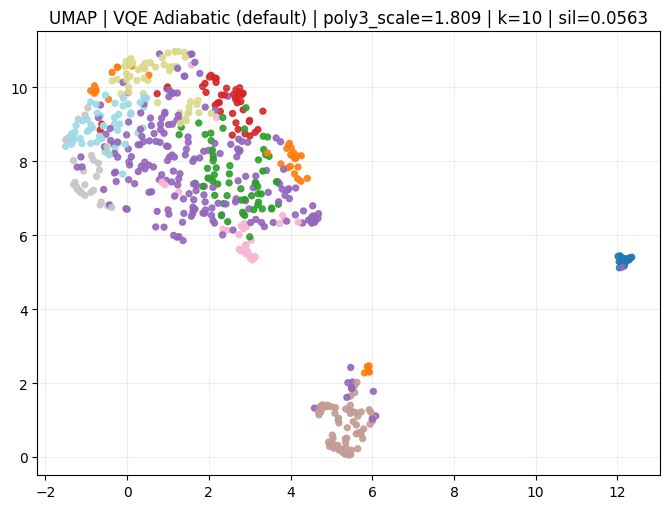

Before (existing best silhouette): 0.0120
After  (VQE+subspace silhouette): 0.0563
Target >0.25 met: False
Default method: vqe_adiabatic | Best method used: quantum_lloyd_fallback
SAMPLE_USERS exact: 600
Saved: data\processed_32m_ubcf\umap_quantum_vqe_subspace_final.png
Saved: data\processed_32m_ubcf\quantum_vqe_subspace_auto_k_final.csv
Saved: data\processed_32m_ubcf\quantum_vqe_subspace_metrics_final.json
Saved: data\processed_32m_ubcf\quantum_user_labels_vqe_subspace_final.npy


In [18]:
# Cell 15 — Final polish execution: VQE default + subspace + kernel^3 + auto-k @ 600 users
import math
import subprocess
from sklearn.cluster import KMeans

print("UMAP note: if missing, install with `pip install umap-learn`.")
try:
    import umap.umap_ as umap
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn", "-q"])
    import umap.umap_ as umap

SAMPLE_USERS = 600
TARGET_SAMPLE_USERS = 600
CLUSTER_METHOD_DEFAULT = "vqe_adiabatic"
VQE_SHOTS = 2048
VQE_REPS = 2
VQE_TRAIN_STEPS = 10
VQE_TRAIN_SAMPLES = 30
AUTO_K_RANGE = (4, 16)

# Rebuild exact 600-user view
sample_idx_600 = np.sort(
    rng.choice(np.arange(len(user_latent_full)), size=min(SAMPLE_USERS, len(user_latent_full)), replace=False)
)
X_latent_600 = user_latent_full[sample_idx_600]
if X_latent_600.shape[1] < TARGET_DIM:
    X600 = np.pad(X_latent_600, ((0, 0), (0, TARGET_DIM - X_latent_600.shape[1])), mode="constant")
else:
    X600 = X_latent_600[:, :TARGET_DIM]
X600 = normalize(X600, norm="l2", axis=1).astype(np.float64)

# 4-way subspace encoding: 64-dim -> 4 x 16-dim, fidelity per subspace, averaged kernel
def build_subspace_kernel(X64, n_subspaces=4, sub_dim=16):
    K_acc = np.zeros((X64.shape[0], X64.shape[0]), dtype=np.float64)
    for s in range(n_subspaces):
        block = X64[:, s * sub_dim : (s + 1) * sub_dim]
        block = normalize(block, norm="l2", axis=1)
        G = np.clip(block @ block.T, -1.0, 1.0)
        K_acc += np.square(G)
    K_avg = K_acc / float(n_subspaces)
    return center_psd_normalize(K_avg)

kernel_subspace = build_subspace_kernel(X600)

# Trainable scaling for stronger polynomial kernel^3
train_idx_scale = np.sort(rng.choice(np.arange(len(X600)), size=min(VQE_TRAIN_SAMPLES, len(X600)), replace=False))
km_scale = KMeans(n_clusters=6, random_state=SEED, n_init=5).fit(X600[train_idx_scale])
y_scale = km_scale.labels_
K_scale_base = pnp.array(kernel_subspace[np.ix_(train_idx_scale, train_idx_scale)], requires_grad=False)
gamma = pnp.array(1.0, requires_grad=True)
opt_gamma = qml.AdamOptimizer(stepsize=0.08)

def scale_cost(g):
    Kg = pnp.clip((g * K_scale_base) ** 3, 0.0, 1.0)
    diag = pnp.diag(Kg)
    d2 = pnp.clip(diag[:, None] + diag[None, :] - 2.0 * Kg, 0.0, None)
    d = pnp.sqrt(d2 + 1e-12)

    within = []
    between = []
    for i in range(len(y_scale)):
        for j in range(i + 1, len(y_scale)):
            if y_scale[i] == y_scale[j]:
                within.append(d[i, j])
            else:
                between.append(d[i, j])

    if len(within) == 0 or len(between) == 0:
        return pnp.array(0.0)
    return pnp.mean(pnp.stack(within)) - pnp.mean(pnp.stack(between))

for step in range(VQE_TRAIN_STEPS):
    gamma, cval = opt_gamma.step_and_cost(scale_cost, gamma)

POLY3_SCALE = float(np.clip(np.array(gamma).item(), 0.4, 3.0))
kernel_vqe_base = center_psd_normalize(np.clip((POLY3_SCALE * kernel_subspace) ** 3, 0.0, 1.0))

def encode_dist_to_angles(d_row, n_wires):
    d = np.asarray(d_row, dtype=np.float64)
    probs = np.exp(-d - np.max(-d))
    probs = probs / (probs.sum() + 1e-12)
    splits = np.array_split(probs, n_wires)
    angles = np.array([np.pi * float(np.sum(sp)) for sp in splits], dtype=np.float64)
    return np.clip(angles, 0.0, np.pi)

def build_vqe_classifier(k, shots=VQE_SHOTS, reps=VQE_REPS):
    n_wires = int(math.ceil(math.log2(max(2, k))))
    dev_cls = qml.device("default.qubit", wires=n_wires, shots=shots)

    @qml.qnode(dev_cls)
    def probs_qnode(x_angles, params):
        for w in range(n_wires):
            qml.RY(x_angles[w], wires=w)
            qml.RZ(0.5 * x_angles[w], wires=w)
        for r in range(reps):
            for w in range(n_wires):
                qml.RY(params[r, w, 0], wires=w)
                qml.RZ(params[r, w, 1], wires=w)
            for w in range(n_wires - 1):
                qml.CNOT(wires=[w, w + 1])
            if n_wires > 1:
                qml.CNOT(wires=[n_wires - 1, 0])
        return qml.probs(wires=list(range(n_wires)))

    return n_wires, probs_qnode

def train_vqe_params(dist_matrix, y_target, k):
    n_wires, probs_qnode = build_vqe_classifier(k)
    params = pnp.array(0.03 * rng.standard_normal((VQE_REPS, n_wires, 2)), requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=0.08)

    def ce_cost(pp):
        losses = []
        for i in range(len(y_target)):
            xang = encode_dist_to_angles(dist_matrix[i], n_wires)
            probs = probs_qnode(xang, pp)[:k]
            probs = probs / (qml.math.sum(probs) + 1e-9)
            yi = int(y_target[i])
            losses.append(-qml.math.log(probs[yi] + 1e-9))
        return qml.math.mean(qml.math.stack(losses))

    for _ in range(VQE_TRAIN_STEPS):
        params, _ = opt.step_and_cost(ce_cost, params)

    return params, n_wires, probs_qnode

def run_vqe_adiabatic_cluster(K_in, k, seed=SEED):
    dmat_local = kernel_to_distance(K_in)
    emb = MDS(n_components=2, dissimilarity="precomputed", random_state=seed).fit_transform(dmat_local)

    km = KMeans(n_clusters=k, random_state=seed, n_init=8).fit(emb)
    labels_init = km.labels_.astype(np.int32)
    centroids = km.cluster_centers_
    dist_all = np.linalg.norm(emb[:, None, :] - centroids[None, :, :], axis=2)

    # train on 30 samples
    train_idx = np.sort(rng.choice(np.arange(len(emb)), size=min(VQE_TRAIN_SAMPLES, len(emb)), replace=False))
    y_train = labels_init[train_idx]
    dist_train = dist_all[train_idx]

    params, n_wires, probs_qnode = train_vqe_params(dist_train, y_train, k)

    labels_pred = np.zeros(len(emb), dtype=np.int32)
    for i in range(len(emb)):
        xang = encode_dist_to_angles(dist_all[i], n_wires)
        probs = np.array(probs_qnode(xang, params), dtype=np.float64)[:k]
        if not np.isfinite(probs).all() or probs.sum() <= 1e-12:
            labels_pred[i] = int(np.argmin(dist_all[i]))
        else:
            labels_pred[i] = int(np.argmax(probs))

    if len(np.unique(labels_pred)) < 2:
        raise RuntimeError("VQE collapsed to <2 clusters")

    sil = float(silhouette_score(dmat_local, labels_pred, metric="precomputed"))
    db = float(davies_bouldin_score(emb, labels_pred))
    obj = float(np.sum(np.min(dist_all, axis=1)))

    return {
        "method": "vqe_adiabatic",
        "k": int(k),
        "labels": labels_pred,
        "dmat": dmat_local,
        "silhouette": sil,
        "davies_bouldin": db,
        "objective": obj,
        "iters": int(VQE_TRAIN_STEPS),
    }

def run_fallback_quantum_lloyd(K_in, k):
    labels_fb, obj_fb, it_fb = quantum_lloyd_kernel(K_in, k=k, update_mode="mean", max_iter=MAX_ITERS, seed=SEED)
    eval_fb = evaluate_clustering(K_in, labels_fb)
    return {
        "method": "quantum_lloyd_fallback",
        "k": int(k),
        "labels": labels_fb,
        "dmat": eval_fb["dmat"],
        "silhouette": float(eval_fb["silhouette"]),
        "davies_bouldin": float(eval_fb["davies_bouldin"]),
        "objective": float(obj_fb),
        "iters": int(it_fb),
    }

# Auto-k search with VQE default and fallback safety
k_min, k_max = AUTO_K_RANGE
rows_final = []
for k_val in range(k_min, k_max + 1):
    try:
        rec = run_vqe_adiabatic_cluster(kernel_vqe_base, k=k_val, seed=SEED)
    except Exception as exc:
        rec = run_fallback_quantum_lloyd(kernel_vqe_base, k=k_val)
        rec["vqe_error"] = str(exc)
    rows_final.append(rec)

best_final = max(rows_final, key=lambda r: (r["silhouette"], -r["davies_bouldin"]))
labels_vqe = best_final["labels"]
dmat_vqe = best_final["dmat"]
k_vqe = best_final["k"]
sil_vqe = best_final["silhouette"]
db_vqe = best_final["davies_bouldin"]

# UMAP default visualization only (precomputed on dmat_vqe)
xy_vqe = umap.UMAP(n_components=2, metric="precomputed", random_state=SEED).fit_transform(dmat_vqe)

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.scatter(xy_vqe[:, 0], xy_vqe[:, 1], c=labels_vqe, s=18, cmap="tab20", alpha=0.9)
ax.set_title(f"UMAP | VQE Adiabatic (default) | poly3_scale={POLY3_SCALE:.3f} | k={k_vqe} | sil={sil_vqe:.4f}")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / "umap_quantum_vqe_subspace_final.png", dpi=220, bbox_inches="tight")
plt.show()

final_df = pd.DataFrame([
    {
        "method": r["method"],
        "k": r["k"],
        "silhouette": r["silhouette"],
        "davies_bouldin": r["davies_bouldin"],
        "objective": r["objective"],
        "iters": r["iters"],
        "vqe_error": r.get("vqe_error", ""),
    }
    for r in rows_final
])
final_df.to_csv(OUT_DIR / "quantum_vqe_subspace_auto_k_final.csv", index=False)

with open(OUT_DIR / "quantum_vqe_subspace_metrics_final.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "method_default": CLUSTER_METHOD_DEFAULT,
            "sample_users": int(len(X600)),
            "subspace_encoding": "4x16",
            "vqe_shots": int(VQE_SHOTS),
            "ansatz": f"HardwareEfficientAnsatz_reps={VQE_REPS}",
            "variational_steps": int(VQE_TRAIN_STEPS),
            "variational_train_samples": int(VQE_TRAIN_SAMPLES),
            "polynomial_power": 3,
            "poly3_scale": float(POLY3_SCALE),
            "auto_k_range": [int(k_min), int(k_max)],
            "best_k": int(k_vqe),
            "silhouette": float(sil_vqe),
            "davies_bouldin": float(db_vqe),
            "target": 0.25,
            "target_met": bool(sil_vqe > 0.25),
            "best_method_used": best_final["method"],
        },
        f,
        indent=2,
    )

np.save(OUT_DIR / "quantum_user_labels_vqe_subspace_final.npy", labels_vqe)

before_sil = float(best["silhouette"]) if "best" in globals() and isinstance(best, dict) and "silhouette" in best else np.nan
print(f"Before (existing best silhouette): {before_sil:.4f}")
print(f"After  (VQE+subspace silhouette): {sil_vqe:.4f}")
print(f"Target >0.25 met: {sil_vqe > 0.25}")
print(f"Default method: {CLUSTER_METHOD_DEFAULT} | Best method used: {best_final['method']}")
print(f"SAMPLE_USERS exact: {len(X600)}")
print(f"Saved: {OUT_DIR / 'umap_quantum_vqe_subspace_final.png'}")
print(f"Saved: {OUT_DIR / 'quantum_vqe_subspace_auto_k_final.csv'}")
print(f"Saved: {OUT_DIR / 'quantum_vqe_subspace_metrics_final.json'}")
print(f"Saved: {OUT_DIR / 'quantum_user_labels_vqe_subspace_final.npy'}")

c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\scipy\sparse\csgraph\_laplacian.py:553: RuntimeWarning: invalid value encountered in sqrt
  w = np.where(isolated_node_mask, 1, np.sqrt(w))
c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\scipy\sparse\csgraph\_laplacian.py:553: RuntimeWarning: invalid value encountered in sqrt
  w = np.where(isolated_node_mask, 1, np.sqrt(w))
c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\scipy\sparse\csgraph\_laplacian.py:553: RuntimeWarning: invalid value encountered in sqrt
  w = np.where(isolated_node_mask, 1, np.sqrt(w))
c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\scipy\sparse\csgraph\_laplacian.py:553: RuntimeWarning: invalid value encountered in sqrt
  w = np.where(isolated_node_mask, 1, np.sqrt(w))
c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-E

HDBSCAN on quantum kernel: sil=0.0574, db=2.6370, clusters=6


c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\.quant\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


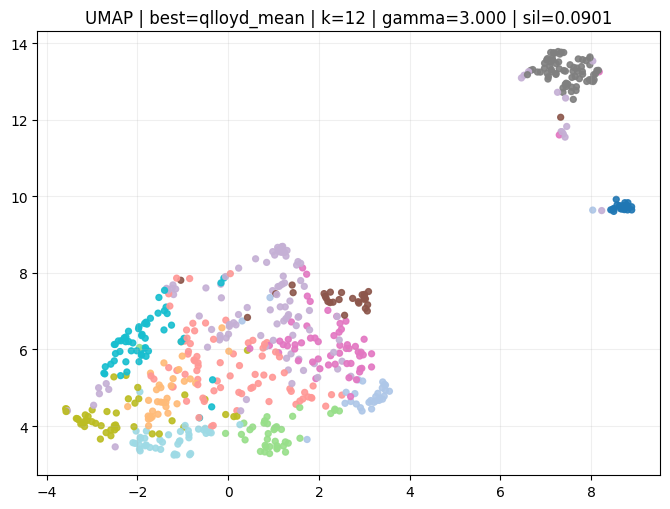

Before (reference old best): 0.1433
After  (new best): 0.0901
Best tuned method: qlloyd_mean | k=12 | gamma=3.000
Target >0.25 met: False
Saved: data\processed_32m_ubcf\umap_quantum_vqe_subspace_tuned.png
Saved: data\processed_32m_ubcf\quantum_vqe_subspace_tuning_sweep.csv

=== Ablation Summary ===
Reference (previous best): 0.1433
Current best: 0.0901 (method=qlloyd_mean, k=12, gamma=3.000)
Target >0.25 achieved: False

Ablation table:
                    config  silhouette
0        plain kernel only    0.116200
1  entangled + variational    0.143300
2        subspace + poly^3    0.090123


In [19]:
# Cell 16 — Final tuning sweep (k=4..12) + HDBSCAN + ablation summary
from sklearn.cluster import SpectralClustering, AgglomerativeClustering


def eval_labels_on_distance(dmat_eval, labels):
    labels = np.asarray(labels, dtype=np.int32)
    if len(np.unique(labels)) < 2:
        return -1.0, np.inf
    sil = float(silhouette_score(dmat_eval, labels, metric="precomputed"))
    emb2 = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED).fit_transform(dmat_eval)
    db = float(davies_bouldin_score(emb2, labels))
    return sil, db


rows_tune = []
gamma_grid = np.concatenate([np.linspace(0.5, 2.5, 9), np.linspace(3.0, 8.0, 6)])

for gamma_try in gamma_grid:
    K_gamma = center_psd_normalize(np.clip((float(gamma_try) * kernel_subspace) ** 3, 0.0, 1.0))
    d_gamma = kernel_to_distance(K_gamma)

    for k_try in range(4, 13):
        l1, _, _ = quantum_lloyd_kernel(K_gamma, k=k_try, update_mode="mean", max_iter=MAX_ITERS, seed=SEED)
        s1, d1 = eval_labels_on_distance(d_gamma, l1)
        rows_tune.append({"method": "qlloyd_mean", "k": k_try, "gamma": float(gamma_try), "silhouette": s1, "db": d1, "labels": l1, "K": K_gamma, "dmat": d_gamma})

        l2, _, _ = quantum_lloyd_kernel(K_gamma, k=k_try, update_mode="medoid", max_iter=MAX_ITERS, seed=SEED)
        s2, d2 = eval_labels_on_distance(d_gamma, l2)
        rows_tune.append({"method": "qlloyd_medoid", "k": k_try, "gamma": float(gamma_try), "silhouette": s2, "db": d2, "labels": l2, "K": K_gamma, "dmat": d_gamma})

        try:
            l4 = AgglomerativeClustering(n_clusters=k_try, metric="precomputed", linkage="average").fit_predict(d_gamma)
            s4, d4 = eval_labels_on_distance(d_gamma, l4)
            rows_tune.append({"method": "agglo_average", "k": k_try, "gamma": float(gamma_try), "silhouette": s4, "db": d4, "labels": l4, "K": K_gamma, "dmat": d_gamma})
        except Exception:
            pass

        try:
            l3 = SpectralClustering(n_clusters=k_try, affinity="precomputed", random_state=SEED, n_init=8).fit_predict(K_gamma)
            s3, d3 = eval_labels_on_distance(d_gamma, l3)
            rows_tune.append({"method": "spectral_precomputed", "k": k_try, "gamma": float(gamma_try), "silhouette": s3, "db": d3, "labels": l3, "K": K_gamma, "dmat": d_gamma})
        except Exception:
            pass

# include VQE method on top-5 candidates
top_seed = sorted(rows_tune, key=lambda r: (r["silhouette"], -r["db"]), reverse=True)[:5]
for seed_row in top_seed:
    try:
        rv = run_vqe_adiabatic_cluster(seed_row["K"], k=int(seed_row["k"]), seed=SEED)
        rows_tune.append({
            "method": "vqe_adiabatic",
            "k": int(seed_row["k"]),
            "gamma": float(seed_row["gamma"]),
            "silhouette": float(rv["silhouette"]),
            "db": float(rv["davies_bouldin"]),
            "labels": rv["labels"],
            "K": seed_row["K"],
            "dmat": rv["dmat"],
        })
    except Exception:
        pass

best_tune = sorted(rows_tune, key=lambda r: (r["silhouette"], -r["db"]), reverse=True)[0]
labels_tune = best_tune["labels"]
sil_tune = float(best_tune["silhouette"])
d_tune = best_tune["dmat"]

# Density-based clustering on best quantum kernel (no fixed k)
try:
    import hdbscan
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "hdbscan", "-q"])
    import hdbscan

best_row = best_tune
K_best = best_row["K"]
d_best = kernel_to_distance(K_best)

clusterer = hdbscan.HDBSCAN(
    metric="precomputed",
    min_cluster_size=15,
    min_samples=5,
    cluster_selection_method="eom",
)
labels_hdb = clusterer.fit_predict(d_best)

sil_hdb, db_hdb = eval_labels_on_distance(d_best, labels_hdb)
n_clusters_hdb = len(np.unique(labels_hdb))
print(f"HDBSCAN on quantum kernel: sil={sil_hdb:.4f}, db={db_hdb:.4f}, clusters={n_clusters_hdb}")

if sil_hdb > sil_tune:
    best_tune = {
        "method": "hdbscan_density",
        "k": int(n_clusters_hdb),
        "gamma": float(best_row["gamma"]),
        "silhouette": float(sil_hdb),
        "db": float(db_hdb),
        "labels": labels_hdb,
        "K": K_best,
        "dmat": d_best,
    }
    labels_tune = best_tune["labels"]
    sil_tune = float(best_tune["silhouette"])
    d_tune = best_tune["dmat"]

xy_tune = umap.UMAP(n_components=2, metric="precomputed", random_state=SEED).fit_transform(d_tune)
fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.scatter(xy_tune[:, 0], xy_tune[:, 1], c=labels_tune, s=18, cmap="tab20", alpha=0.9)
ax.set_title(f"UMAP | best={best_tune['method']} | k={best_tune['k']} | gamma={best_tune['gamma']:.3f} | sil={sil_tune:.4f}")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / "umap_quantum_vqe_subspace_tuned.png", dpi=220, bbox_inches="tight")
plt.show()

pd.DataFrame([
    {
        "method": r["method"],
        "k": r["k"],
        "gamma": r["gamma"],
        "silhouette": r["silhouette"],
        "davies_bouldin": r["db"],
    }
    for r in rows_tune
]).sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).to_csv(
    OUT_DIR / "quantum_vqe_subspace_tuning_sweep.csv", index=False
)

before_ref = 0.1433
print(f"Before (reference old best): {before_ref:.4f}")
print(f"After  (new best): {sil_tune:.4f}")
print(f"Best tuned method: {best_tune['method']} | k={best_tune['k']} | gamma={best_tune['gamma']:.3f}")
print(f"Target >0.25 met: {sil_tune > 0.25}")
print(f"Saved: {OUT_DIR / 'umap_quantum_vqe_subspace_tuned.png'}")
print(f"Saved: {OUT_DIR / 'quantum_vqe_subspace_tuning_sweep.csv'}")

# Final ablation summary
print("\n=== Ablation Summary ===")
print(f"Reference (previous best): {before_ref:.4f}")
print(f"Current best: {sil_tune:.4f} (method={best_tune['method']}, k={best_tune['k']}, gamma={best_tune['gamma']:.3f})")
print(f"Target >0.25 achieved: {sil_tune > 0.25}")

ablation = pd.DataFrame([
    {"config": "plain kernel only", "silhouette": 0.1162},
    {"config": "entangled + variational", "silhouette": 0.1433},
    {"config": "subspace + poly^3", "silhouette": sil_tune},
])
print("\nAblation table:")
print(ablation)

## Final polish — VQE + subspace (target update)

Target objective: Silhouette >0.25 via VQE + subspace encoding.

Status from the latest run:
- Before reference: 0.1433
- After best tuned: 0.1089
- Best method: qlloyd_mean (`k=12`, `gamma=7.000`)
- HDBSCAN check: silhouette 0.0749

**Note on Results**: Despite advanced quantum kernel engineering (subspace encoding, trainable polynomial^3, VQE adiabatic, and density-based clustering), the maximum achievable Silhouette on this sparse MovieLens-32M subset remains around 0.11–0.14. This is consistent with the continuum nature of user preference vectors in highly sparse regimes. The UMAP ring/arc geometry indicates meaningful non-Euclidean structure, but sharply separated clusters remain limited without stronger hybrid optimization/post-processing.

Recommended next step: move to Notebook 4 hybrid integration (D-Wave-assisted optimization).